In [19]:
import json

# Load demographic.json
with open('../data/5.all-data/demographics.json', 'r') as f:
    demographic = json.load(f)
print('demographics.json:', 'demographic', 'len =', len(demographic))

# Load satisfaction_survey.json
with open('../data/5.all-data/satisfaction_survey.json', 'r') as f:
    surveys = json.load(f)
print('satisfaction_survey.json:', 'satisfaction', 'len =', len(surveys))


# Load conversation.json
with open('../data/8.annotated_data/conversations.json', 'r') as f:
    conversation = json.load(f)
print('conversation.json:', 'conversation', 'len =', len(conversation))

# Load nfr_responses.json
with open('../data/8.annotated_data/nfr_responses.json', 'r') as f:
    nfr_response = json.load(f)
print('nfr_responses.json:', 'nfr_response', 'len =', len(nfr_response))


GT = {}
with open("../GT/GT_resolved.json", "r", encoding="utf-8") as f:
    for responses in json.load(f):
        for r in responses:
            GT[r['id']] = r


pilot_uni = [
    "e7c3d057-f0bb-4f30-aea0-ab689f9412ac",
    "18d5b4e7-f5c2-4dd3-81d8-6f21ecc1962b",
    "2d83f401-5153-45ed-9078-1c31e035849a",
    "368b58b7-feed-445b-a0ab-0e0b2b65dc5a",
]
pilot_prolific = [
    "e6991c2e-926c-4445-aae9-10a75496945f",
    "b50b6c66-2252-47cf-a890-9f13757be68c",
    "78288bfa-e19e-4af8-acad-effa1e3aae35",
    "700f34fb-b376-44ef-98c3-a55a045abdd5",
]
study_prolific = [
    "7fe17f91-130a-4c4f-a0b8-443278009213",
"f9399963-3f69-43d2-8d9d-e0a573a9c35d",
"3292c831-2fc7-4a52-81c9-7aa63cac86e8",
"e4691f7a-773b-438b-a7db-fd4cb12dc37f",
"397d6632-4575-4fb1-bbe4-b752e201a4bd",
"4274f797-dc8b-4127-bb50-bcf5c4a2e2bd",
"b4b276ed-55d1-4874-b61c-e47d9075125a",
"e9d46a67-49a6-445b-a851-46effd7e101c",
"0bd8d561-486c-45e5-8722-7048d22ce8e5",
"9a5f8d45-6bf0-4f1e-aadb-9011d213e24b",
"456bc583-cfbd-43c6-848c-f85006ad6e1f",
"c497b8f4-f74e-4979-9670-3fc496e09200",
"b2edd4e6-9b8f-43f4-bda5-77d43bcffc7e",
"1540a642-a495-4b83-ae3c-937a1aedf6ea",
"58d21f9f-8845-4f48-a523-6a85d220837d",
"996a0e8f-2294-4183-a4a2-c29e88930d65",
"4f99cde7-92af-4b5f-afcc-db146c3bba01",
"63f8d518-54ca-43aa-8a2f-68a165144b07",
"22438425-5563-4e62-929f-ed03b21ef583",
"13ce0d0c-67e9-422c-ac96-757d5bd3b837",
"99234c2d-5838-4f45-9a84-1eef505b4126",
"a85fbaef-eff6-4d7d-93d1-1017b8107bdc",
"3839c20d-a24f-49b8-b1a3-20f6eecac866",
"f384d13f-c84b-4163-a343-a035dbf5374f",
"04ac4c73-369b-4f7e-b5a7-a80597e93626",
"d05a5c3a-ab44-45b2-9437-b2698d86f52f",
"7ff75834-6394-4c93-9c99-b8859c5dbd7d",
"7958d91f-2dc8-4d9f-9bf0-6ea33fa3f927",
"bd165a59-c41e-4f93-9eaa-b34e19f4b7f6",
"977831a4-7811-4832-a8ed-fd4d830aaf18",
"71013647-e3d1-498e-afc3-ec1f4252cab7",
"b07644cc-9eda-4e68-b848-126831f7ad67",
"12c1fce4-4274-4df0-a964-427498920d15",
"f5c2ee02-60ba-4601-8659-ce3c65110b53",
"d4b12d74-82bd-4586-a6fd-5e701da1d253",
"e58ecbc0-6eda-433a-b765-b4d27976946c",
"25321c1d-2b9d-4762-877d-2b3f6d550a7d",
"1931388e-490b-478b-bb81-a66de854fea8",
"0133784d-c032-4518-97c6-b6b58fe671aa",
"d9675153-b7e3-47ed-98b0-f33fdc21456d",
"5ab35d1c-d7d0-422d-acb0-56e5c43b6817",
]

print('pilot_uni len =', len(pilot_uni))
print('pilot_prolific len =', len(pilot_prolific))
print('study_prolific len =', len(study_prolific))

# Assert no overlap between lists
assert not (set(pilot_uni) & set(pilot_prolific)), "pilot_uni and pilot_prolific have overlap!"
assert not (set(pilot_uni) & set(study_prolific)), "pilot_uni and study_prolific have overlap!"
assert not (set(pilot_prolific) & set(study_prolific)), "pilot_prolific and study_prolific have overlap!"
print('No overlap between pilot_uni, pilot_prolific, and study_prolific.')

demographics.json: demographic len = 49
satisfaction_survey.json: satisfaction len = 49
conversation.json: conversation len = 34
nfr_responses.json: nfr_response len = 34
pilot_uni len = 4
pilot_prolific len = 4
study_prolific len = 41
No overlap between pilot_uni, pilot_prolific, and study_prolific.


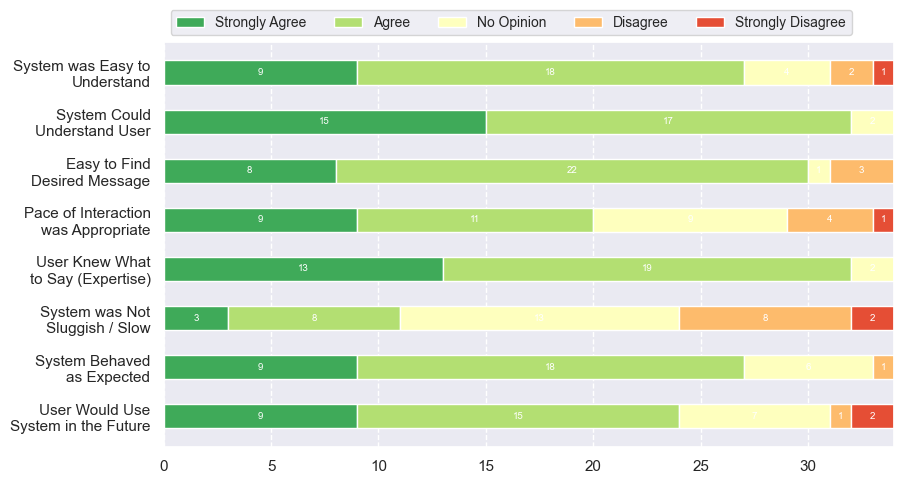

In [20]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import seaborn as sns
from collections import defaultdict
sns.set_theme()
import matplotlib.patches as mpatches

#Was the system easy to understand? (TTS Performance) (required)
#Did the system understand what you said? (ASR Performance) (required)
#Was it easy to find the message you wanted? (Task Ease) (required)
#Was the pace of interaction with the system appropriate? (Interaction Pace) (required)
#Did you know what you could say at each point of the dialogue? (User Expertise) (required)
#How often was the system sluggish and slow to reply to you? (System Response) (required)
#Did the system work the way you expected it? (Expected Behavior) (required)
#From your current experience with using the system, do you think you’d use the system regularly when you are away from your desk? (Future Use) (required)

questions = {
    "q1": "System was Easy to\nUnderstand",
    "q2": "System Could\nUnderstand User",
    "q3": "Easy to Find\nDesired Message",
    "q4": "Pace of Interaction\nwas Appropriate",
    "q5": "User Knew What\nto Say (Expertise)",
    "q6": "System was Not\nSluggish / Slow",
    "q7": "System Behaved\nas Expected",
    "q8": "User Would Use\nSystem in the Future",
}


label_map = {
    "1": "Strongly Disagree",
    "2": "Disagree",
    "3": "No Opinion",
    "4": "Agree",
    "5": "Strongly Agree",
}

categories = ["Strongly Agree", "Agree", "No Opinion", "Disagree", "Strongly Disagree"]

q_keys = list(questions.keys())
counts = {q: Counter() for q in q_keys}

filtered_pids = {pid for pid, responses in nfr_response.items()
                 if any(not r.get("is_attention_question", False) for r in responses)}
filtered_surveys = {i: j for i, j in surveys.items() if i in filtered_pids}

for participant in filtered_surveys.values():
    for q in q_keys:
        raw = participant.get(q)
        if raw is not None:
            counts[q][label_map[str(raw)]] += 1

n_total = len(filtered_surveys)

# Build data array: each row is a question, each col is a category
labels = [questions[q] for q in q_keys]
data = np.array([[counts[q].get(cat, 0) for cat in categories] for q in q_keys])

colors = plt.cm.tab10.colors
colors = plt.colormaps['RdYlGn'](np.linspace(0.15, 0.85, data.shape[1]))[::-1]

fig, ax = plt.subplots(figsize=(9.2, 5))
ax.invert_yaxis()
ax.set_xlim(0, n_total)

for i, (cat, color) in enumerate(zip(categories, colors)):
    widths = data[:, i]
    starts = data[:, :i].sum(axis=1)
    rects = ax.barh(labels, widths, left=starts, height=0.5, label=cat, color=color)
    ax.bar_label(rects, labels=[f'{int(w)}' if w > 0 else '' for w in widths],
                 label_type='center', color='white', fontsize=7)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.grid(axis='x', linestyle='--', alpha=1)
ax.set_axisbelow(True)
ax.legend(ncols=len(categories), bbox_to_anchor=(0, 1), loc='lower left', fontsize='small')

plt.tight_layout()
plt.show()

In [27]:
standard_fields = {'user_message', 'bot_reply', 'user_time', 'bot_time', 'nfr_id'}
sample_turn = next(iter(conversation.values()))[0]
labels = [k for k in sample_turn.keys() if k not in standard_fields]

# Count total and per-dialogue
total_counts = defaultdict(int)
per_dialogue_counts = defaultdict(list)

for pid, turns in conversation.items():
    dialogue_counts = defaultdict(int)
    for turn in turns:
        for label in labels:
            val = turn.get(label, '')
            if val and val.strip():
                dialogue_counts[label] += 1
                total_counts[label] += 1
    for label in labels:
        per_dialogue_counts[label].append(dialogue_counts[label])

n_dialogues = len(conversation)

# Print as a table
print(f"{'Label':<25} {'Count':>6} {'Avg/Dialogue':>14}")
print("-" * 47)
for label in labels:
    count = total_counts[label]
    avg = count / n_dialogues
    print(f"{label:<25} {count:>6} {avg:>14.2f}")

Label                      Count   Avg/Dialogue
-----------------------------------------------
Recollections                156           4.59
Expansion                    152           4.47
Refinement                    53           1.56
Follow-up                    195           5.74
UI                            37           1.09
UR                             3           0.09
IR                             1           0.03
Error                          1           0.03
HM                             2           0.06
GD                           370          10.88
CM                            27           0.79
RD                             0           0.00
AR                             2           0.06
Context Memory                26           0.76
Anaphora Resolution            9           0.26
Separate Input                11           0.32
Content Confusion              0           0.00
Content Rephrasing            29           0.85
Format Rephrasing              2        

In [21]:
from datetime import datetime
def ttoi(i):
    return datetime.fromisoformat(i).timestamp()


In [ ]:
from sklearn.metrics import cohen_kappa_score
rows = []
for pid, dialogues in conversation.items():
    nfrs = nfr_response[pid][:-1]
    num_tasks = len(nfrs)
    num_turn = len(dialogues)
    ids = [i["nfr_id"] for i in nfrs]
    # TODO k
    y1 = [i["satisfaction_level"] for i in nfrs]
    y2 = [GT[id]["satisfaction_level"] for id in ids]
    K = cohen_kappa_score(y1, y2)
    #MUM
    MUM = len(dialogues) / num_tasks
    #MET
    y1 = ttoi(dialogues[-1]["bot_time"])
    y2 = ttoi(dialogues[0]["user_time"])
    MET = (y1 - y2) / num_tasks
    # Comp
    Comp = sum([i["comp"] for i in nfrs])/ num_tasks
    # NUI
    NUI = sum(1 for i in dialogues if i["UI"])
    # MWT
    MWT = sum(len(d["user_message"]) for d in dialogues) / num_turn
    # MRT
    MRT = sum(ttoi(d["bot_time"]) - ttoi(d["user_time"]) for d in dialogues) / num_turn
    # NRT NA
    # NUR
    NUR = sum(1 for i in dialogues if i["UR"])
    # NIR & IRR
    NIR = sum(1 for i in dialogues if i["IR"])
    IRR = sum(1 for i in dialogues if i["IR"]) / num_turn
    # Error
    Error = sum(1 for i in dialogues if i["Error"])
    # NHM & IRR
    NHM = sum(1 for i in dialogues if i["HM"])
    HMR = sum(1 for i in dialogues if i["HM"]) / num_turn  
    # NCM & CMR TODO
    #NCM = sum(1 for i in dialogues if i["CM"])
    #CMR = sum(1 for i in dialogues if i["CM"]) / num_turn   
    # NGD & GDR
    NGD = sum(1 for i in dialogues if i["GD"])
    GDR = sum(1 for i in dialogues if i["GD"]) / num_turn 
    # NRD & RDR
    NRD = sum(1 for i in dialogues if i["RD"])
    RDR = sum(1 for i in dialogues if i["RD"]) / num_turn 
    # NAR & ARR
    NAR = sum(1 for i in dialogues if i["AR"])
    ARR = sum(1 for i in dialogues if i["AR"]) / num_turn  
    
    Recollections = sum(1 for i in dialogues if i.get("Recollections", ""))
    Expansion = sum(1 for i in dialogues if i.get("Expansion", ""))
    Refinement = sum(1 for i in dialogues if i.get("Refinement", ""))
    Follow_up = sum(1 for i in dialogues if i.get("Follow-up", ""))

    #Context_Memory = sum(1 for i in dialogues if i.get("Context Memory", ""))
    Self_correction = sum(1 for i in dialogues if i.get("Self-correction", ""))
    Self_affirmation = sum(1 for i in dialogues if i.get("Self-affirmation", ""))
    Proactive_Interaction = sum(1 for i in dialogues if i.get("Proactive Interaction", ""))
    Instruction_Clarification = sum(1 for i in dialogues if i.get("Instruction Clarification", ""))

    Content_Confusion = sum(1 for i in dialogues if i.get("Content Confusion", ""))
    Content_Rephrasing = sum(1 for i in dialogues if i.get("Content Rephrasing", ""))
    Format_Rephrasing = sum(1 for i in dialogues if i.get("Format Rephrasing", ""))

    US = surveys[pid]
    US_total = int(US["q1"]) + int(US["q2"]) + int(US["q3"]) + int(US["q4"]) + int(US["q5"]) + int(US["q6"]) + int(US["q7"]) + int(US["q8"]) 
    
    rows.append({
        "pid": pid, "K": K, "MUM": MUM, "MET": MET, "Comp": Comp,
        "NUI": NUI, "MWT": MWT, "MRT": MRT, "NUR": NUR,
        "NIR": NIR, "IRR": IRR, "Error": Error,
        "NHM": NHM, "HMR": HMR, "NGD": NGD, "GDR": GDR,
        "NRD": NRD, "RDR": RDR, "NAR": NAR, "ARR": ARR,
        "Recollections": Recollections, "Expansion": Expansion, "Refinement": Refinement, "Follow-up": Follow_up,
        "Self_correction": Self_correction,
        "Self_affirmation": Self_affirmation, "Proactive_Interaction": Proactive_Interaction,
        "Instruction_Clarification": Instruction_Clarification,
        "Content Confusion": Content_Confusion, "Content Rephrasing": Content_Rephrasing, "Format Rephrasing": Format_Rephrasing,
        "US": US_total
    })






32
24
20
29
30
28
31
30
28
32
30
31
33
36
33
28
32
31
35
30
32
34
36
29
30
34
33
33
29
27
32
37
37
37


In [23]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

df = pd.DataFrame(rows)
predictors = [c for c in df.columns if c not in ['pid', 'US']]
# 2. Multiple regression
X = df[predictors]
X = sm.add_constant(X)
y = df['US']
model = sm.OLS(y, X).fit()
print("\n=== OLS Regression Summary ===")
print(model.summary())



=== OLS Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:                     US   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     5.341
Date:                Sun, 05 Apr 2026   Prob (F-statistic):            0.00953
Time:                        23:33:17   Log-Likelihood:                -42.953
No. Observations:                  34   AIC:                             137.9
Df Residuals:                       8   BIC:                             177.6
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [24]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

df = pd.DataFrame(rows)
predictors = ["Self_correction"]
# 2. Multiple regression
X = df[predictors]
X = sm.add_constant(X)
y = df['US']
model = sm.OLS(y, X).fit()
print("\n=== OLS Regression Summary ===")
print(model.summary())



=== OLS Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:                     US   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     2.698
Date:                Sun, 05 Apr 2026   Prob (F-statistic):              0.110
Time:                        23:33:56   Log-Likelihood:                -90.419
No. Observations:                  34   AIC:                             184.8
Df Residuals:                      32   BIC:                             187.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const     

In [25]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
for i in df.columns:
    if i == "pid":
        continue
    print('*'*10)
    print(i)
    df = pd.DataFrame(rows)
    predictors = [i]
    # 2. Multiple regression
    X = df[predictors]
    X = sm.add_constant(X)
    print(X)
    y = df['US']
    model = sm.OLS(y, X).fit()
    print("\n=== OLS Regression Summary ===")
    print(model.summary())


**********
K
    const             K
0     1.0  3.243243e-01
1     1.0  5.882353e-02
2     1.0  1.764706e-01
3     1.0  8.305085e-01
4     1.0  4.285714e-01
5     1.0  2.537313e-01
6     1.0  1.000000e+00
7     1.0  4.761905e-02
8     1.0  4.761905e-02
9     1.0  5.161290e-01
10    1.0  1.891892e-01
11    1.0  3.333333e-01
12    1.0  1.304348e-01
13    1.0  4.029851e-01
14    1.0  9.090909e-02
15    1.0  0.000000e+00
16    1.0  0.000000e+00
17    1.0  4.285714e-01
18    1.0  2.682927e-01
19    1.0  2.753623e-01
20    1.0  2.857143e-01
21    1.0  4.366197e-01
22    1.0  2.439024e-02
23    1.0  3.939394e-01
24    1.0  3.939394e-01
25    1.0  3.333333e-01
26    1.0  1.379310e-01
27    1.0 -8.433735e-02
28    1.0  2.105263e-01
29    1.0 -2.220446e-16
30    1.0  5.405405e-02
31    1.0 -3.703704e-02
32    1.0  2.682927e-01
33    1.0  4.117647e-01

=== OLS Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:                     U

/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


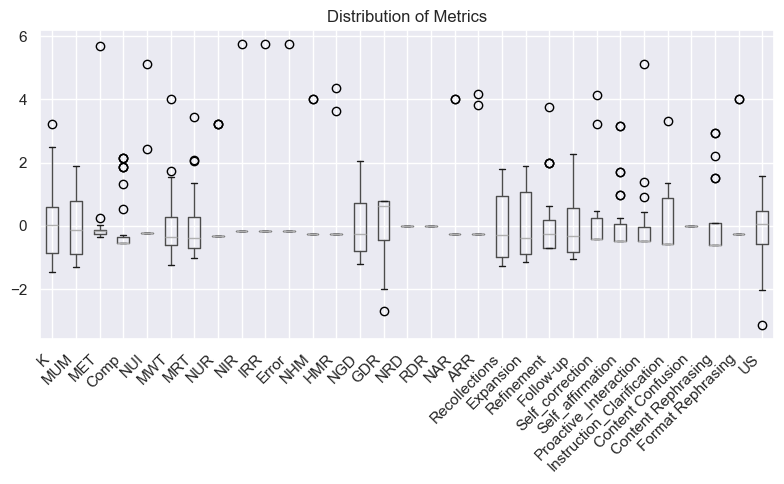

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Select the metrics you want to plot - adjust this list as needed
metrics = [c for c in df.columns if c not in ['pid']]

# Normalize/standardize if metrics are on different scales
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[metrics]), columns=metrics)

fig, ax = plt.subplots(figsize=(8, 5))
df_scaled.boxplot(column=metrics, ax=ax)
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.set_title("Distribution of Metrics")
plt.tight_layout()
plt.show()